# Problem Statement

We have the data of the lead content in the tap water before and after flushing.


Before Flushing (First Draw - pb_1 in data): 

When water sits unused in pipes for several hours (like overnight), it can pick up lead from the pipes or solder, especially in older plumbing systems. The "Before Flushing" sample is usually the very first water drawn from the tap after this period of stagnation. It represents the water that was sitting directly in the faucet and the pipes right behind it, and often has the highest lead concentration.

After Flushing (pb_3 in data): 

"Flushing" simply means running the tap water for a certain amount of time (e.g., a few minutes). This clears out the stagnant water that was sitting in the building's pipes and draws in fresher water from the water main serving the house. The "After Flushing" sample is collected after this flushing period. It's intended to measure the lead level in the water coming into the house from the distribution system, after the influence of the home's immediate plumbing has been reduced.

Goal 

- Comparing the "Before Flushing" and "After Flushing" levels helps understand:

- How much lead might be coming from the building's internal plumbing (the difference between the two samples).

- Whether flushing the tap is an effective way to reduce lead exposure at that specific location.

# Importing Libraries & Data

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Loading dataset

In [15]:
file_name = 'flint.csv'
df_flint = pd.read_csv(file_name)

# Data Exploration

In [17]:
print("\nFirst 5 rows of the dataset:")
print(df_flint.head())


First 5 rows of the dataset:
   sample_id    zip  ward   pb_1    pb_2   pb_3
0          1  48504     6  0.344   0.226  0.145
1          2  48507     9  8.133  10.770  2.761
2          4  48504     1  1.111   0.110  0.123
3          5  48507     8  8.007   7.446  3.384
4          6  48505     3  1.951   0.048  0.035


In [20]:
print("\nDataset Information:")
df_flint.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271 entries, 0 to 270
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  271 non-null    int64  
 1   zip        271 non-null    int64  
 2   ward       271 non-null    int64  
 3   pb_1       271 non-null    float64
 4   pb_2       271 non-null    float64
 5   pb_3       271 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 12.8 KB


In [28]:
#Checking duplicates & Null

num_duplicates = df_flint.duplicated().sum()
num_duplicates

0

In [30]:
null_counts = df_flint.isnull().sum()
null_counts

sample_id    0
zip          0
ward         0
pb_1         0
pb_2         0
pb_3         0
dtype: int64

In [32]:
#Renaming columns 'pb_1' and 'pb_3' for clarity
# We assume pb_1 is 'Before Flushing' and pb_3 is 'After Flushing'
df_flint = df_flint.rename(columns={
    'pb_1': 'Lead_Before_Flushing',
    'pb_3': 'Lead_After_Flushing'
})
print("\nColumns 'pb_1' and 'pb_3' renamed for clarity.")
print("Renamed columns preview:")
print(df_flint.head())


Columns 'pb_1' and 'pb_3' renamed for clarity.
Renamed columns preview:
   sample_id    zip  ward  Lead_Before_Flushing    pb_2  Lead_After_Flushing
0          1  48504     6                 0.344   0.226                0.145
1          2  48507     9                 8.133  10.770                2.761
2          4  48504     1                 1.111   0.110                0.123
3          5  48507     8                 8.007   7.446                3.384
4          6  48505     3                 1.951   0.048                0.035


# Exploratory Data Analysis

In [35]:
#Creating DataFrame containing only the columns we need
# and remove any rows where either lead value is missing (NaN).
# This prevents errors in calculations and plots.
analysis_cols = ['Lead_Before_Flushing', 'Lead_After_Flushing']
df_analysis = df_flint[analysis_cols].dropna()
print(f"Using {len(df_analysis)} samples for analysis (rows with missing lead values removed).")

Using 271 samples for analysis (rows with missing lead values removed).


In [37]:
#Summary

summary_stats = df_analysis.describe()
print("Summary Statistics for Lead Concentrations:")
print(summary_stats)

Summary Statistics for Lead Concentrations:
       Lead_Before_Flushing  Lead_After_Flushing
count            271.000000           271.000000
mean              10.645993             3.660705
std               21.560778            10.538500
min                0.344000             0.031000
25%                1.578000             0.306000
50%                3.521000             0.831000
75%                9.050000             2.740500
max              158.000000            94.520000


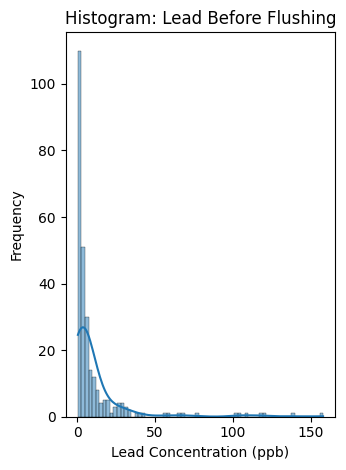

In [49]:
#Creating Histrogram to show the distribution of data

# Plot histogram for 'Lead_Before_Flushing'
plt.subplot(1, 2, 1) # Create subplot 1 (1 row, 2 columns, 1st plot)
sns.histplot(data=df_analysis, x='Lead_Before_Flushing', kde=True) # kde adds the curve
plt.title('Histogram: Lead Before Flushing')
plt.xlabel('Lead Concentration (ppb)')
plt.ylabel('Frequency')
plt.tight_layout() # Adjust plot spacing to prevent overlap
plt.show()

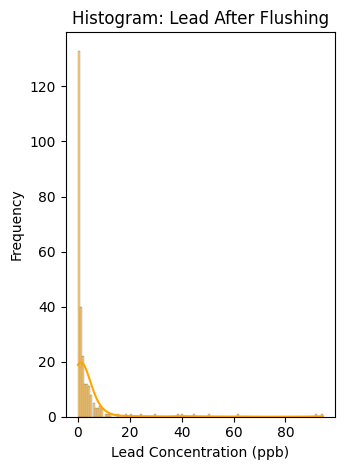

In [47]:
# Plot histogram for 'Lead_After_Flushing'
plt.subplot(1, 2, 2) # Create subplot 2 (1 row, 2 columns, 2nd plot)
sns.histplot(data=df_analysis, x='Lead_After_Flushing', kde=True, color='orange')
plt.title('Histogram: Lead After Flushing')
plt.xlabel('Lead Concentration (ppb)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

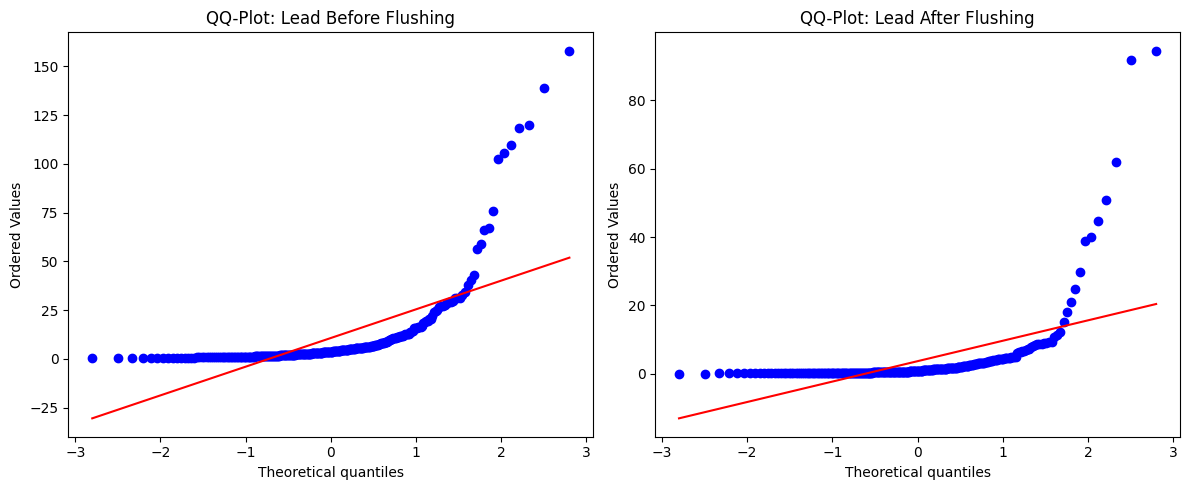

In [51]:
plt.figure(figsize=(12, 5)) 

# Plot QQ-plot for 'Lead_Before_Flushing'
plt.subplot(1, 2, 1)
stats.probplot(df_analysis['Lead_Before_Flushing'], dist="norm", plot=plt)
plt.title('QQ-Plot: Lead Before Flushing')

# Plot QQ-plot for 'Lead_After_Flushing'
plt.subplot(1, 2, 2) 
stats.probplot(df_analysis['Lead_After_Flushing'], dist="norm", plot=plt)
plt.title('QQ-Plot: Lead After Flushing')

plt.tight_layout()
plt.show()

In [55]:
#Correlation

# Calculating the correlation coefficient between the two columns.
# Correlation measures the linear relationship (-1 to +1).
correlation_value = df_analysis['Lead_Before_Flushing'].corr(df_analysis['Lead_After_Flushing'])
print(f"Correlation between Lead Before and After Flushing: {correlation_value:.4f}")

Correlation between Lead Before and After Flushing: 0.5513


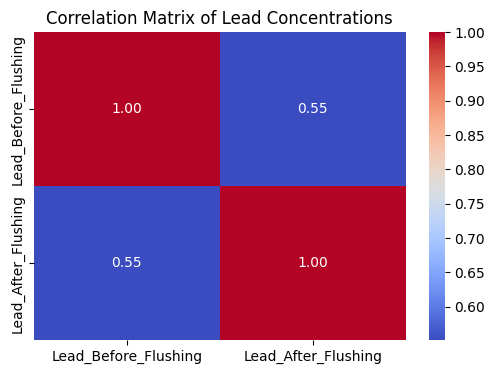

In [57]:
# Visualizing the correlations between all columns in df_analysis using a heatmap.
plt.figure(figsize=(6, 4))
# sns.heatmap creates a color-coded map of the correlation values.
# annot=True displays the values on the map. cmap sets the color scheme. fmt=".2f" formats numbers.
sns.heatmap(df_analysis.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Lead Concentrations')
plt.show()

# Paired T-Test

In [62]:
#Comparing mean lead concentrations before and after flushing.

t_statistic, p_value = stats.ttest_rel(df_analysis['Lead_Before_Flushing'], df_analysis['Lead_After_Flushing'])

# Print the results
print(f"\nPaired T-Test Results:")
print(f"T-statistic: {t_statistic:.4f}") # Shows how many standard errors the mean difference is away from zero
print(f"P-value: {p_value}") # Probability of observing the data (or more extreme) if H0 is true


Paired T-Test Results:
T-statistic: 6.3748
P-value: 7.891488687174298e-10


In [64]:
# Interpreting the Results
print("\nInterpretation Guidance:")
# We compare the p-value to a significance level (alpha), usually 0.05.
alpha = 0.05
print(f"Significance level (alpha) = {alpha}")


Interpretation Guidance:
Significance level (alpha) = 0.05


In [66]:
# To see the direction of the change , we can calculate the mean difference:
mean_before = df_analysis['Lead_Before_Flushing'].mean()
mean_after = df_analysis['Lead_After_Flushing'].mean()
mean_difference = mean_before - mean_after
print(f"\nMean Lead Concentration Before Flushing: {mean_before:.2f} ppb")
print(f"Mean Lead Concentration After Flushing: {mean_after:.2f} ppb")
print(f"Mean Difference (Before - After): {mean_difference:.2f} ppb")


Mean Lead Concentration Before Flushing: 10.65 ppb
Mean Lead Concentration After Flushing: 3.66 ppb
Mean Difference (Before - After): 6.99 ppb


# Data Visualisation

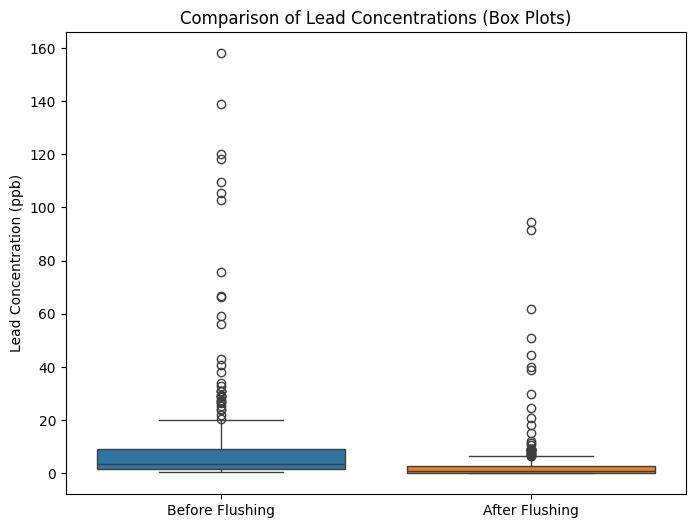

In [71]:
#Box Plots

# Box plots are useful for comparing the distribution (median, spread, outliers)
# of numerical data across different groups. Here, our groups are 'Before' and 'After'.

plt.figure(figsize=(8, 6)) 

sns.boxplot(data=df_analysis[['Lead_Before_Flushing', 'Lead_After_Flushing']])

plt.title('Comparison of Lead Concentrations (Box Plots)')
plt.ylabel('Lead Concentration (ppb)')

plt.xticks(ticks=[0, 1], labels=['Before Flushing', 'After Flushing'])
plt.show()

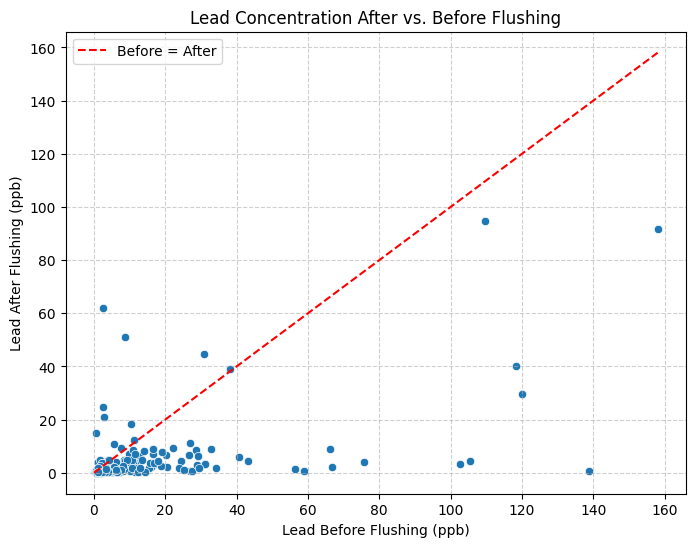

In [77]:
#Scatter Plot

# Scatter plots show the relationship between two numerical variables.
# Each point represents one sample location.

plt.figure(figsize=(8, 6)) 
# Create the scatter plot using seaborn
sns.scatterplot(data=df_analysis, x='Lead_Before_Flushing', y='Lead_After_Flushing')

#y=x reference line. Points below this line show
# where the concentration decreased after flushing.
max_val = max(df_analysis['Lead_Before_Flushing'].max(), df_analysis['Lead_After_Flushing'].max())
min_val = min(df_analysis['Lead_Before_Flushing'].min(), df_analysis['Lead_After_Flushing'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Before = After')

# Add titles and labels
plt.title('Lead Concentration After vs. Before Flushing')
plt.xlabel('Lead Before Flushing (ppb)')
plt.ylabel('Lead After Flushing (ppb)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend() 
plt.show() 


# Advanced Analysis

In [89]:
# Outlier Identification (IQR Method)
# Outliers are data points that are unusually far from the other points.
# The Interquartile Range (IQR) method is a common way to identify them.

# Calculate Q1 (25th percentile), Q3 (75th percentile), and IQR for 'Before Flushing'
Q1_before = df_analysis['Lead_Before_Flushing'].quantile(0.25)
Q3_before = df_analysis['Lead_Before_Flushing'].quantile(0.75)
IQR_before = Q3_before - Q1_before
# Define outlier bounds
lower_bound_before = Q1_before - 1.5 * IQR_before
upper_bound_before = Q3_before + 1.5 * IQR_before

# Calculate Q1, Q3, and IQR for 'After Flushing'
Q1_after = df_analysis['Lead_After_Flushing'].quantile(0.25)
Q3_after = df_analysis['Lead_After_Flushing'].quantile(0.75)
IQR_after = Q3_after - Q1_after
# Define outlier bounds
lower_bound_after = Q1_after - 1.5 * IQR_after
upper_bound_after = Q3_after + 1.5 * IQR_after




In [91]:
# Count how many data points fall outside these bounds
#We are just identifying them here, not removing them.
num_outliers_before = df_analysis[
    (df_analysis['Lead_Before_Flushing'] < lower_bound_before) |
    (df_analysis['Lead_Before_Flushing'] > upper_bound_before)
].shape[0] # .shape[0] gives the count of rows

num_outliers_after = df_analysis[
    (df_analysis['Lead_After_Flushing'] < lower_bound_after) |
    (df_analysis['Lead_After_Flushing'] > upper_bound_after)
].shape[0]

print(f"Outlier Bounds (Before): < {lower_bound_before:.2f} or > {upper_bound_before:.2f}")
print(f"Number of potential outliers detected (Before Flushing): {num_outliers_before}")
print(f"Outlier Bounds (After): < {lower_bound_after:.2f} or > {upper_bound_after:.2f}")
print(f"Number of potential outliers detected (After Flushing): {num_outliers_after}")

Outlier Bounds (Before): < -9.63 or > 20.26
Number of potential outliers detected (Before Flushing): 33
Outlier Bounds (After): < -3.35 or > 6.39
Number of potential outliers detected (After Flushing): 30


# Linear Regression Analysis

In [87]:
# We want to model the relationship: Lead_After_Flushing = b0 + b1 * Lead_Before_Flushing
# where b0 is the intercept and b1 is the slope.

# Define independent variable (X - the predictor)
X = df_analysis['Lead_Before_Flushing']
# Define dependent variable (y - the variable we want to predict)
y = df_analysis['Lead_After_Flushing']

# Add a constant (intercept) term to the independent variable(s)

X_with_const = sm.add_constant(X)

# Create the Ordinary Least Squares (OLS) model
# OLS is the standard method for linear regression.
model = sm.OLS(y, X_with_const)

# Fit the model to the data
results = model.fit()

# Print the detailed summary of the regression results
print("\nOLS Regression Results Summary:")
print(results.summary())


OLS Regression Results Summary:
                             OLS Regression Results                            
Dep. Variable:     Lead_After_Flushing   R-squared:                       0.304
Model:                             OLS   Adj. R-squared:                  0.301
Method:                  Least Squares   F-statistic:                     117.5
Date:                 Tue, 29 Apr 2025   Prob (F-statistic):           5.98e-23
Time:                         18:13:35   Log-Likelihood:                -973.15
No. Observations:                  271   AIC:                             1950.
Df Residuals:                      269   BIC:                             1958.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

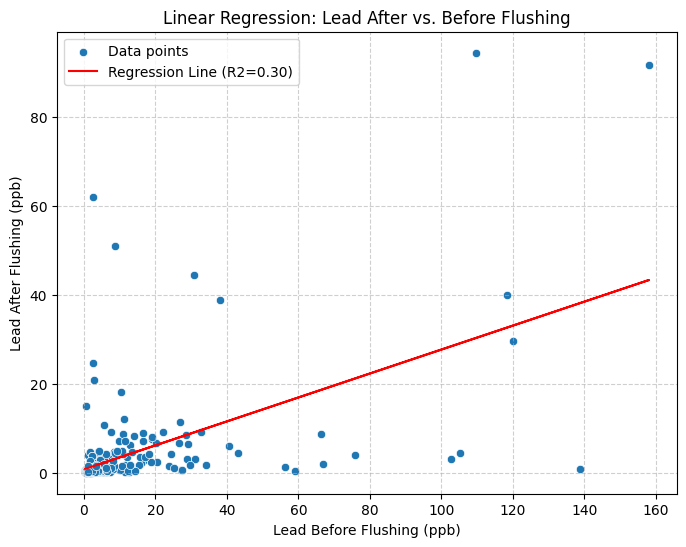

In [95]:
#Visualizing the regression line on the scatter plot

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_analysis, x='Lead_Before_Flushing', y='Lead_After_Flushing', label='Data points')
# Plotting the regression line using the fitted model's predictions
plt.plot(X, results.predict(X_with_const), color='red', label=f'Regression Line (R2={results.rsquared:.2f})')
plt.title('Linear Regression: Lead After vs. Before Flushing')
plt.xlabel('Lead Before Flushing (ppb)')
plt.ylabel('Lead After Flushing (ppb)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


## Analysis Conclusion

This analysis explored the Flint water sampling data (`flint.csv`) using Python, with the primary goal of understanding the relationship between lead concentrations in water samples taken **before** and **after** flushing the tap.

**Key Findings:**

* **Effectiveness of Flushing:** A paired t-test confirmed a **statistically significant decrease** in lead concentrations after flushing compared to before flushing (p < 0.0001). On average, lead levels were considerably lower after running the water, suggesting flushing is generally beneficial for reducing immediate lead exposure from stagnant plumbing.
* **Data Variability and Outliers:** Both pre-flush and post-flush data showed **high variability** and the presence of significant **outliers** (very high readings). This indicates that while the average reduction is significant, some locations experience persistently high lead levels even after flushing, posing potential health risks. These outliers also skew the average (mean) values higher than the median.
* **Relationship Modeling:**
    * A **moderate positive correlation (r ≈ 0.55)** was found between lead levels before and after flushing.
    * Linear regression analysis yielded a statistically significant model (`Lead_After_Flushing ≈ 0.79 + 0.27 * Lead_Before_Flushing`). This confirms that higher lead levels before flushing are associated with higher levels after flushing.
    * However, the model's **R-squared value was relatively low (≈ 0.30)**. This is a crucial finding: it means that the lead concentration before flushing only explains about 30% of the variability in the concentration found after flushing.

**Overall Takeaway:**

While the analysis demonstrates that flushing taps is an effective practice on average for reducing lead concentration, the relationship between pre- and post-flush levels is not perfectly predictable. The significant variability, presence of high outliers, and the low R-squared value highlight that other factors heavily influence lead levels after flushing. This Python-based analysis successfully quantified the average benefit of flushing while also revealing the complexity and persistent risks indicated within the dataset.